# Phishing Website Detection
**AI4ALL Project - Group 13B**

## Project Description
This project uses machine learning to detect phishing websites.
We train models to classify websites as phishing or legitimate.
We use two datasets to make our model more reliable.

## Datasets
- **Kaggle:** 10,000 websites, 48 features
- **UCI:** 11,055 websites, 30 features

## Team Members
- Aarushi Arora
- Varija Manglik
- Leah Wang
- Zheng Zhang
- Shreeshkumar Lillyprabhu

## Project Roadmap

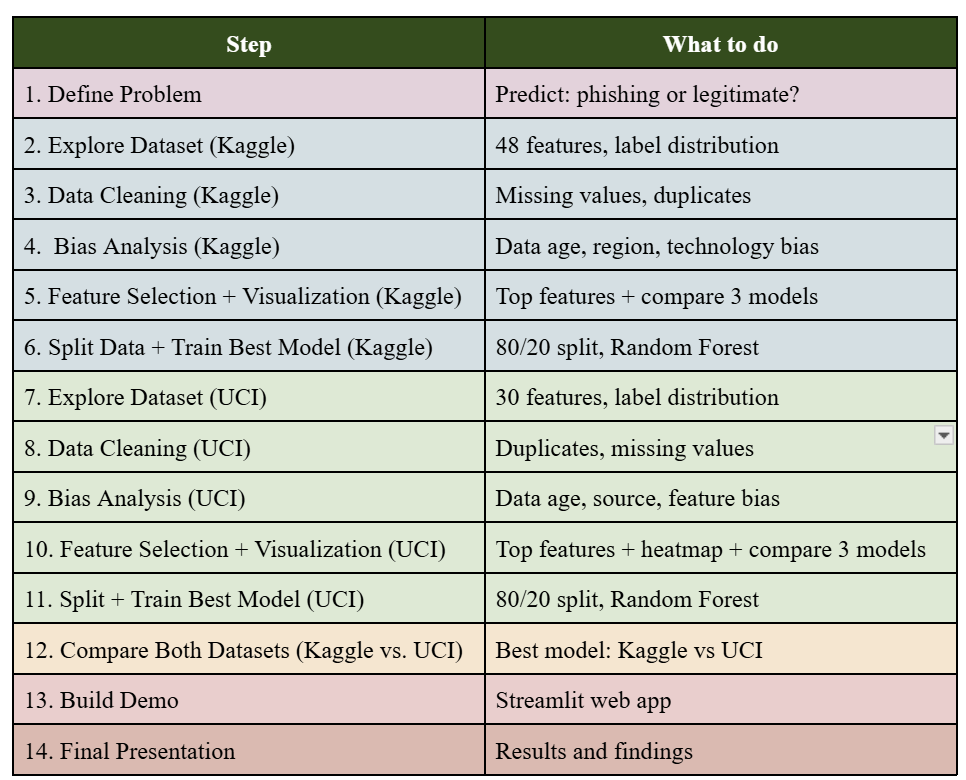


Dataset loaded! Shape: (10000, 50)

--------------------------------------- First 5 Rows (Kaggle) ---------------------------------------


,Feature,0,1,2,3,4,Feature,0,1,2,3,4
0,id,1.00,2.00,3.00,4.00,5.00,NumSensitiveWords,0.00,1.00,0.00,0.00,0.00
1,NumDots,3.00,3.00,3.00,3.00,3.00,EmbeddedBrandName,0.00,0.00,0.00,1.00,0.00
2,SubdomainLevel,1.00,1.00,1.00,1.00,0.00,PctExtHyperlinks,0.00,0.00,0.38,1.00,1.00
3,PathLevel,5.00,3.00,2.00,6.00,4.00,PctExtResourceUrls,0.25,0.00,1.00,0.10,1.00
4,UrlLength,72.00,144.00,58.00,79.00,46.00,ExtFavicon,1.00,0.00,1.00,1.00,0.00
5,NumDash,0.00,0.00,0.00,1.00,0.00,InsecureForms,1.00,1.00,1.00,1.00,0.00
6,NumDashInHostname,0.00,0.00,0.00,0.00,0.00,RelativeFormAction,0.00,0.00,0.00,0.00,0.00
7,AtSymbol,0.00,0.00,0.00,0.00,0.00,ExtFormAction,0.00,0.00,0.00,0.00,1.00
8,TildeSymbol,0.00,0.00,0.00,0.00,0.00,AbnormalFormAction,0.00,0.00,0.00,0.00,0.00
9,NumUnderscore,0.00,2.00,0.00,0.00,0.00,PctNullSelfRedirectHyperlinks,0.00,0.00,0.00,0.00,0.00



--------------------------------------- Label Count (Kaggle) ---------------------------------------


,count
CLASS_LABEL,
Phishing,5000
Legitimate,5000


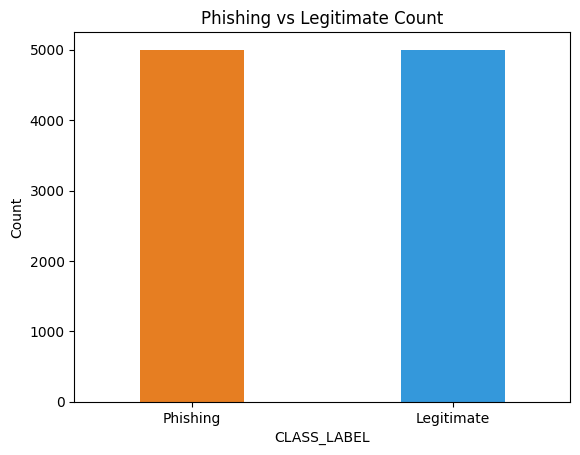


--------------------------------------- Missing Values (Kaggle) ---------------------------------------


,Feature,Missing,Feature,Missing,Feature,Missing
0,id,0,IpAddress,0,PctNullSelfRedirectHyperlinks,0.0
1,NumDots,0,DomainInSubdomains,0,FrequentDomainNameMismatch,0.0
2,SubdomainLevel,0,DomainInPaths,0,FakeLinkInStatusBar,0.0
3,PathLevel,0,HttpsInHostname,0,RightClickDisabled,0.0
4,UrlLength,0,HostnameLength,0,PopUpWindow,0.0
5,NumDash,0,PathLength,0,SubmitInfoToEmail,0.0
6,NumDashInHostname,0,QueryLength,0,IframeOrFrame,0.0
7,AtSymbol,0,DoubleSlashInPath,0,MissingTitle,0.0
8,TildeSymbol,0,NumSensitiveWords,0,ImagesOnlyInForm,0.0
9,NumUnderscore,0,EmbeddedBrandName,0,SubdomainLevelRT,0.0



--------------------------------------- Stats Summary (Kaggle) ---------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.50,2886.90,1.0,2500.75,5000.50,7500.25,10000.0
NumDots,10000.0,2.45,1.35,1.0,2.00,2.00,3.00,21.0
SubdomainLevel,10000.0,0.59,0.75,0.0,0.00,1.00,1.00,14.0
PathLevel,10000.0,3.30,1.86,0.0,2.00,3.00,4.00,18.0
UrlLength,10000.0,70.26,33.37,12.0,48.00,62.00,84.00,253.0
NumDash,10000.0,1.82,3.11,0.0,0.00,0.00,2.00,55.0
NumDashInHostname,10000.0,0.14,0.55,0.0,0.00,0.00,0.00,9.0
AtSymbol,10000.0,0.00,0.02,0.0,0.00,0.00,0.00,1.0
TildeSymbol,10000.0,0.01,0.11,0.0,0.00,0.00,0.00,1.0
NumUnderscore,10000.0,0.32,1.11,0.0,0.00,0.00,0.00,18.0


In [36]:
# Step 2: Explore Dataset (Kaggle)
# Goal: load the data and look at it before cleaning.
import pandas as pd
import matplotlib.pyplot as plt

# Format: numbers show 2 decimals, text stays the same
def fmt(v):
    return f"{v:.2f}" if isinstance(v, (int, float)) else v

# Load Kaggle dataset
df = pd.read_csv('Phishing_Legitimate_full.csv')
print("Dataset loaded! Shape:", df.shape)   # rows, columns

# === First 5 Rows ===
# Transpose + split into 2 groups (25 + 25) so it's not too long
print("\n--------------------------------------- First 5 Rows (Kaggle) ---------------------------------------")
head_T = df.head().T.reset_index()
head_T.columns = ['Feature', '0', '1', '2', '3', '4']
n = 25
groups = [head_T.iloc[i:i+n].reset_index(drop=True) for i in range(0, len(head_T), n)]
head_wide = pd.concat(groups, axis=1).fillna('')
display(head_wide.style.format(fmt).set_table_attributes('style="width:1000px"'))

# === Label Count ===
# 1 = Phishing, 0 = Legitimate
print("\n--------------------------------------- Label Count (Kaggle) ---------------------------------------")
label_df = df['CLASS_LABEL'].value_counts().rename({1: 'Phishing', 0: 'Legitimate'}).to_frame()
display(label_df.style.set_table_attributes('style="width:1000px"'))

# Bar chart. Easy to see the 50/50 balance.
df['CLASS_LABEL'].value_counts().rename({1: 'Phishing', 0: 'Legitimate'}).plot(
    kind='bar',
    color=['#e67e22', '#3498db'],
    width=0.4,
    title='Phishing vs Legitimate Count'
)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# === Missing Values ===
# Check all 50 columns. Split into 3 groups (17 + 17 + 16) so it's not too long.
print("\n--------------------------------------- Missing Values (Kaggle) ---------------------------------------")
missing = df.isnull().sum()
n = 17
mgroups = []
for i in range(0, len(missing), n):
    g = missing.iloc[i:i+n].reset_index()
    g.columns = ['Feature', 'Missing']
    mgroups.append(g.reset_index(drop=True))
missing_wide = pd.concat(mgroups, axis=1).fillna('')
display(missing_wide)

# === Stats Summary ===
# Basic stats for each column (min, max, mean, etc.)
print("\n--------------------------------------- Stats Summary (Kaggle) ---------------------------------------")
display(df.describe().round(2).T)

## Step 2 Summary - Explore Dataset (Kaggle)

### What we found:
- Total data: **10,000 websites** (5,000 phishing + 5,000 legitimate)
- Total features: **48 features** (50 columns with id + label)
- Missing values: **None** (data is clean)
- Labels are **perfectly balanced** (50% vs 50%)

### What this means:
- Data is ready for cleaning
- No need to fix missing values
- Balanced data = fair model training

### Next step:
-> Step 3: Data Cleaning (Kaggle) 

In [33]:
# Step 3: Data Cleaning (Kaggle)
import pandas as pd

# Load Kaggle dataset
df = pd.read_csv('Phishing_Legitimate_full.csv')

# Check duplicates
print("-------------------- Duplicates --------------------")
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Check missing values
print("\n-------------------- Missing Values --------------------")
print(df.isnull().sum().sum(), "total missing values")

# Drop 'id' column (just a row number, not useful for training)
df = df.drop(columns=['id'])
print("\nDropped 'id' column")
print("New shape:", df.shape)

# Final check
print("\n-------------------- Clean Dataset Ready --------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Show head, split into 2 groups (so it's not too long)
head_T = df.head().T.reset_index()
head_T.columns = ['Feature', '0', '1', '2', '3', '4']
n = 25
groups = [head_T.iloc[i:i+n].reset_index(drop=True) for i in range(0, len(head_T), n)]
head_wide = pd.concat(groups, axis=1).fillna('')

# Format: numbers show 2 decimals, text stays the same
def fmt(v):
    return f"{v:.2f}" if isinstance(v, (int, float)) else v

caption_style = [{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', 'black')]}]
display(head_wide.style.format(fmt).set_table_attributes('style="width:1000px"').set_caption("First 5 Rows (Clean Dataset)").set_table_styles(caption_style))

-------------------- Duplicates --------------------
Duplicate rows: 0
After removing duplicates: (10000, 50)

-------------------- Missing Values --------------------
0 total missing values

Dropped 'id' column
New shape: (10000, 49)

-------------------- Clean Dataset Ready --------------------
Rows: 10000
Columns: 49


,Feature,0,1,2,3,4,Feature,0,1,2,3,4
0,NumDots,3.00,3.00,3.00,3.00,3.00,EmbeddedBrandName,0.00,0.00,0.00,1.00,0.00
1,SubdomainLevel,1.00,1.00,1.00,1.00,0.00,PctExtHyperlinks,0.00,0.00,0.38,1.00,1.00
2,PathLevel,5.00,3.00,2.00,6.00,4.00,PctExtResourceUrls,0.25,0.00,1.00,0.10,1.00
3,UrlLength,72.00,144.00,58.00,79.00,46.00,ExtFavicon,1.00,0.00,1.00,1.00,0.00
4,NumDash,0.00,0.00,0.00,1.00,0.00,InsecureForms,1.00,1.00,1.00,1.00,0.00
5,NumDashInHostname,0.00,0.00,0.00,0.00,0.00,RelativeFormAction,0.00,0.00,0.00,0.00,0.00
6,AtSymbol,0.00,0.00,0.00,0.00,0.00,ExtFormAction,0.00,0.00,0.00,0.00,1.00
7,TildeSymbol,0.00,0.00,0.00,0.00,0.00,AbnormalFormAction,0.00,0.00,0.00,0.00,0.00
8,NumUnderscore,0.00,2.00,0.00,0.00,0.00,PctNullSelfRedirectHyperlinks,0.00,0.00,0.00,0.00,0.00
9,NumPercent,0.00,0.00,0.00,0.00,0.00,FrequentDomainNameMismatch,0.00,0.00,0.00,1.00,1.00


## Step 3 Summary - Data Cleaning (Kaggle)

### What we did:
- Checked duplicate rows and removed them
- Checked missing values
- Dropped the `id` column (just a row number, not useful for training)

### What we found:
- Duplicate rows: **0** (no duplicates)
- Missing values: **0** (data is complete)
- Final shape: **10,000 rows, 49 columns** (48 features + label)

### What this means:
- Data is clean and ready
- No duplicates = no repeated data
- No missing values = no empty data
- Dropping `id` = model focuses on real features only

### Next step:
-> Step 4: Bias Analysis (Kaggle)

## Step 4: Bias Analysis (Kaggle)

### What is bias?
Bias means our data or model may not be fair or correct for every case.

### Sources of bias in the Kaggle dataset:

**1. Time Bias**
- The data was collected a few years ago
- Phishing tricks change fast
- New attack types may not be in the data

**2. Region Bias**
- We don't know which countries or languages the sites are from
- Phishing patterns can differ by region

**3. Feature Bias**
- Only 48 features were collected
- Some new phishing signs may not be covered

### How we reduce bias:
- Use a balanced dataset (5,000 phishing + 5,000 legitimate)
- Test 3 different models and compare
- Use 80/20 train/test split for fair evaluation
- Also test on a second dataset (UCI) to check our model

### Next step:
-> Step 5: Feature Selection + Visualization (Kaggle)

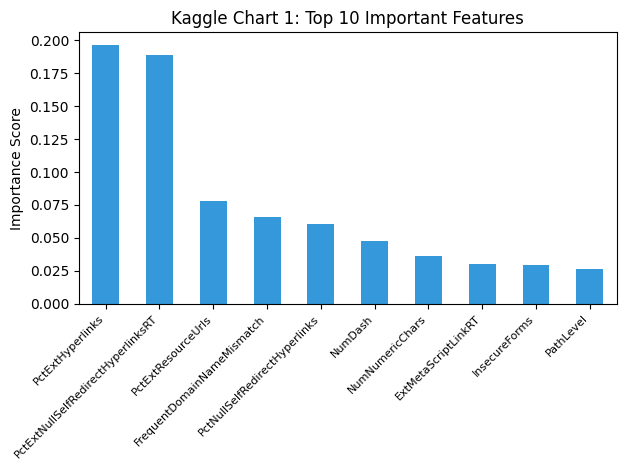

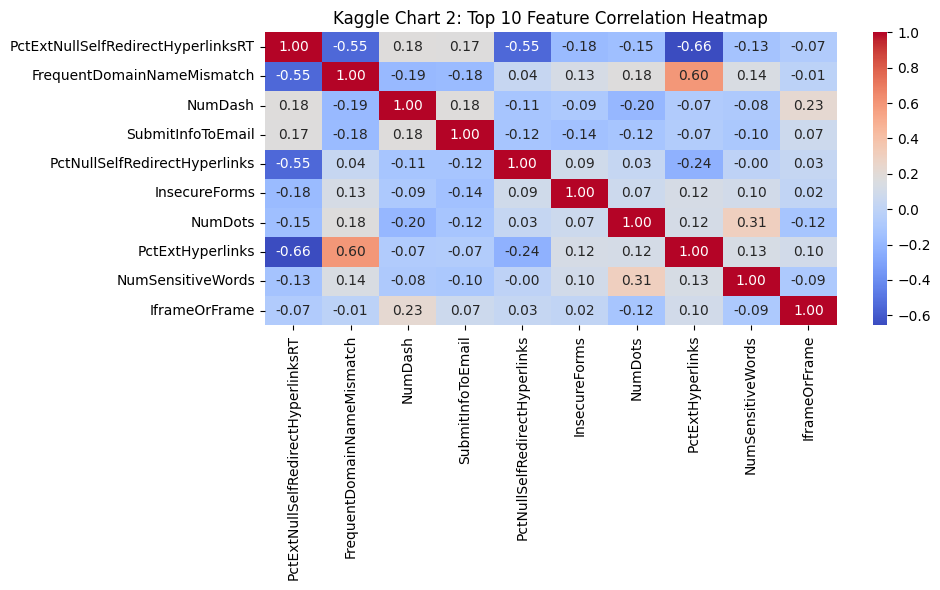

------------------------ Kaggle Model Comparison ------------------------
Logistic Regression: 95.20%
Decision Tree: 96.40%
Random Forest: 98.55%


In [34]:
# Step 5: Feature Selection + Visualization (Kaggle)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load clean data
df = pd.read_csv('Phishing_Legitimate_full.csv')
df = df.drop(columns=['id'])

# X = features (input), y = label (output)
X = df.drop(columns=['CLASS_LABEL'])
y = df['CLASS_LABEL']

# Chart 1: Top 10 important features
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)[:10].plot(
    kind='bar', color='#3498db', title='Kaggle Chart 1: Top 10 Important Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Chart 2: Correlation heatmap (top 10 features most related to label)
top_features = df.corr()['CLASS_LABEL'].abs().sort_values(ascending=False)[1:11].index
plt.figure(figsize=(10, 6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Kaggle Chart 2: Top 10 Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Compare 3 models (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
print("------------------------ Kaggle Model Comparison ------------------------")
for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc*100:.2f}%")

## Step 5 Summary - Feature Selection + Visualization (Kaggle)

### What we found:

**Chart 1: Top 10 Important Features**
- PctExtHyperlinks is the most important feature
- These features are about suspicious links in websites

**Chart 2: Correlation Heatmap**
- Red = features that work together
- Blue = features that are opposite

**Model Comparison Results:**

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 95.20% |
| Decision Tree | 96.40% |
| Random Forest | 98.55% |

### Conclusion:
- Random Forest is the best model (98.55%)
- It correctly detects about 98 out of 100 websites

### Next step:
-> Step 6: Split Data + Train Best Model (Kaggle)

Kaggle Accuracy: 98.55 %

=== Report ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1000
    Phishing       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



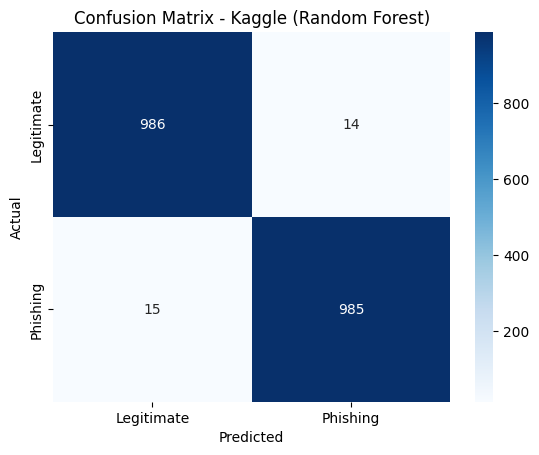

In [35]:
# Step 6: Split Data + Train Best Model (Kaggle)
# Use Kaggle data. Train Random Forest (best from Step 5). Check results.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split data. stratify keeps 50/50 balance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest (best model)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test data
y_pred = rf.predict(X_test)

# Accuracy
kaggle_acc = accuracy_score(y_test, y_pred)
print("Kaggle Accuracy:", round(kaggle_acc * 100, 2), "%")

# Full report. Recall = how many phishing sites we caught. This matters most.
print("\n=== Report ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Confusion matrix. Shows right vs wrong predictions.
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Kaggle (Random Forest)')
plt.show()

## Step 6 Summary - Split Data + Train Best Model (Kaggle)

### What we found:

**Accuracy:** 98.55%

**Report (Phishing class):**
- Precision = 98.60% (when it says phishing, it is right 98.60% of the time)
- Recall = 98.50% (it catches 98.50% of phishing sites)

**Confusion Matrix:**

| | Predicted Legit | Predicted Phishing |
|---|---|---|
| Actual Legit | 986 (correct) | 14 (false alarm) |
| Actual Phishing | 15 (missed) | 985 (caught) |

### What this means:
- The model catches almost all phishing sites
- It misses only 15 phishing sites out of 1000
- False alarms are low (only 14)

### Conclusion:
- Random Forest works very well on the Kaggle data
- High recall is good. We do not want to miss phishing sites.

### Next step:
-> Step 7: Explore Dataset (UCI)